# Quantitative analysis of a Student's t random walk

This report investigates **random walks with Student's t distributed shocks** as a way to model financial returns with **heavy tails**. We simulate multiple random walks, analyze their statistical properties, and compare them to Gaussian random walks. Key aspects studied include **distributional moments**, **histograms**, **QQ plots**, **power-law behavior of tails**, and **autocorrelation of returns**. The goal is to illustrate how heavy-tailed distributions alone can reproduce extreme events seen in real markets, without requiring temporal correlations or volatility clustering.

# Table of Contents

1. [Python Libraries](#1-python-libraries)
2. [Methodology](#2-methodology)
   - [Construction of a Student's t random walk](#21-construction-of-a-students-t-random-walk)
   - [Simulating multiple Student's t random walks simultaneously](#22-multiple-students-t-random-walks)
   - [Construction of returns](#23-construction-of-returns)
3. [Statistical properties of the return distribution](#3-statistical-properties-of-the-return-distribution)
   - [Four moments of the return distribution](#31-four-moments-of-the-return-distribution)
        - [Discussion on the apparent skewness of the distribution](#311-discussion-on-the-apparent-skewness-of-the-distributionn)
   - [Histogram of returns](#32-histogram-of-returns)
   - [QQ plot vs. Normal for different degrees of freedom](#33-qq-plot-vs-normal-for-different-degrees-of-freedom)
4. [Discussion of heavy tails](#4-discussion-of-heavy-tails)
   - [Estimation of the alpha exponent](#41-estimation-of-the-alpha-exponentt)
5. [Autocorrelation](#5-autocorrelation)
6. [Summary of empirical findings and implications](#6-summary-of-empirical-findings-and-implications)
7. [References](#7-references)
8. [Appendix](#8-appendix)

## 1. Python Libraries 

- **numpy** for numerical processing and logarithmic transformations.
- **matplotlib** for technical visualization of time series and distributions.
- **scipy** for performing statistical tests.
- **statsmodels** for building regressions.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

from scipy.stats import linregress 
from scipy.stats import skew 
from scipy.stats import kurtosis 
from scipy.stats import norm 
from scipy.stats import probplot 

from statsmodels.graphics.tsaplots import plot_acf  

## 2. Methodology

### 2.1 Construction of a Student's t random walk

Each price value is generated as the previous value plus a random shock or noise, which in this case follows a Student’s t-distribution:

$$
X_t = X_{t-1} + \epsilon_t
$$

where 

$$
\epsilon_t \sim t(\nu)
$$

Key parameters include the number of steps **T** (each step represents one day), the average daily return **$\mu$**, and the initial price **$P_0$**. For the Student's t random walk, we also have the degrees of freedom parameter **$\nu$**, which controls the heaviness of the tails, and the **scale** **s** (analogous to standard deviation, although we usually talk in terms of scale). The scale $s$ is related to the standard deviation **$\sigma$** as:

$$
\sigma^2 = s^2 \frac{\nu}{\nu - 2}, \quad \text{for } \nu > 2
$$

Each $X_t$ is constructed as a **cumulative sum** of shocks using `cumsum()`:

$$
X_t = X_{t-1} + \epsilon_t = X_{t-2} + \epsilon_{t-1} + \epsilon_t = \dots = X_0 + \epsilon_1 + \dots + \epsilon_t
$$

In other words, building the random walk simply requires **accumulating the sum of random shocks** over time.

A practical issue with this approach is that the resulting value can theoretically become negative, which is not meaningful for prices. To fix this, we can transform the walk into a **log-price model**:

$$
\sum x_i = \ln\left(\frac{S_t}{S_0}\right) \implies S_t = S_0 \cdot e^{\sum x_i}
$$

where $x_i$ represents the return between day $i$ and day $i-1$, and each step is drawn from a Student’s t-distribution.

Since we know the relationship between scale and standard deviation, we can calculate $s$ as $s(\nu, \sigma)$ to easily compare with other distributions. The key point is that the NumPy function `np.random.standard_t` generates a **standardized version**, centered at zero with a predefined scale. Therefore, returns **$\epsilon$** are constructed manually as: 

$$\epsilon = \mu + \text{np.random.standard t(df, size)} \times s $$

> By doing this, we simply **shift the distribution** with a drift $\mu$ and **stretch/compress it** with the scale $s$, while keeping the distribution fully symmetric.

> Setting a **random seed** ensures that the generated random path is the same each time the program runs, which is crucial for **reproducibility** of results.




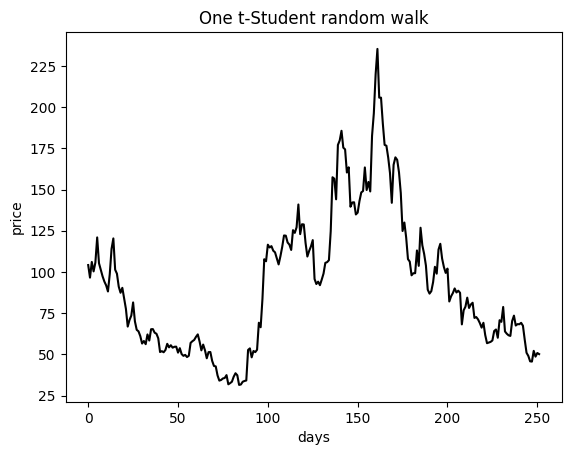

In [13]:
np.random.seed(42)

nu = 4 #degrees of freedom
mu = 0.0005 #daily mean return
T = 252 #traiding days in a year 
S0 = 100 #initial price

sigma = 0.01 #daily standard deviation
s = math.sqrt(sigma*(nu-2)/nu) #scale 

epsilon = mu + s*np.random.standard_t(df=nu, size=T) #a random variable for each step 
S = S0*np.exp(np.cumsum(epsilon))

fig, ax = plt.subplots()

ax.plot(S, color = "black")
ax.set_title("One t-Student random walk")
ax.set_xlabel("days")
ax.set_ylabel("price")

plt.show()


## 2.2 Simulating multiple Student's t random walks simultaneously

We can easily **plot multiple random walks** simultaneously.


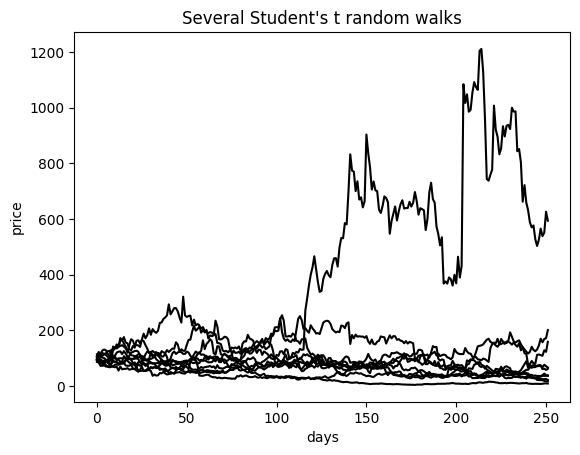

In [14]:
np.random.seed(42)
N = 10 #number of random walks

epsilon = mu + s*np.random.standard_t(df=nu, size=(T,N))
S = S0*np.exp(np.cumsum(epsilon, axis=0))

fig, ax = plt.subplots()

ax.plot(S, color = "black")
ax.set_title("Several Student's t random walks")
ax.set_xlabel("days")
ax.set_ylabel("price")

plt.show()

## 2.3 Construction of returns

Since returns that follow a t-Student distribution are theoretically **i.i.d.** (their independence does not depend on being t-Student or Gaussian, but on the way they are generated randomly), we could use returns from multiple random walks to increase the number of data points, just as we did in the Gaussian case (see proyect: *analysis gaussian random walk*).

However, we will only **construct returns from a single random walk**, because we know that the aggregation of non-Gaussian returns (in our case, t-Student) converges **slowly** to a Gaussian distribution according to the **Central Limit Theorem**. Therefore, it is convenient to control the number of data points we work with at all times, which is easier if we focus on a single random walk.

> A caveat: this reasoning is not entirely precise. Strictly speaking, convergence to a Gaussian would occur when **aggregating multiple random walks**, each following the same distribution (here, the t-Student). For a single t-Student random walk, the only way for the distribution of returns to approach normality is by adjusting the **degrees of freedom**. 

In [15]:
np.random.seed(42)

nu = 3 
mu = 0.0005 
sigma = 0.01 
T = 10000 
S0 = 100 

sigma = 0.01
s = math.sqrt(sigma*(nu-2)/nu) 

epsilon = mu + s*np.random.standard_t(df=nu, size=T)
S = S0*np.exp(np.cumsum(epsilon))


returns = np.diff(np.log(S))
returns = returns[~np.isnan(returns)]

## 3. Statistical properties of the return distribution

### 3.1 Four moments of the return distribution

To begin, we calculate the **mean**, **variance**, **skewness**, and **kurtosis**, as these might be very useful when studying the potential presence of **heavy tails**.

In [16]:
print(f"Mean: {np.mean(returns):.4f}")
print(f"Standard deviation: {np.std(returns):.4f}")
print(f"Skewness: {skew(returns):.4f}")
print(f"Excess kurtosis: {kurtosis(returns):.4f}")

Mean: 0.0004
Standard deviation: 0.0959
Skewness: 0.2567
Excess kurtosis: 20.5154


The skewness is moderate, but the **excess kurtosis** is extremely high, indicating the presence of **heavy tails**.

#### 3.1.1 Discussion on the apparent skewness of the distribution

Adding a **drift** to the generation of $\epsilon$ (each random step following the t-Student distribution) only shifts the distribution left or right. This has **nothing to do with skewness**, which measures the asymmetry between the two sides of the distribution relative to the mean. The **Standard Error of Skewness (SES)** is approximately calculated as:

$$
SES \approx \sqrt{\frac{6}{n}}
$$

where $n$ is the number of observations.
 
A common rule of thumb is that if the calculated skewness exceeds **twice the SES**, it is considered statistically significant. In our case, with 10,000 data points, skewness would be significant beyond approximately ±0.05. Thus, the observed skewness could appear considerable.

However, we must note that our distribution has only **3 degrees of freedom** (close to the limit where variance becomes infinite). This means extreme values (outliers) are quite likely, which can produce disproportionate skewness. We can quickly test this by simulating skewness for $T = 20,000$ or more, and we would see that skewness varies significantly. Therefore, although skewness may appear large, we can consider our distribution **essentially symmetric**, as the apparent asymmetry is caused by a few highly probable outliers.

> Increasing the number of degrees of freedom would produce a more stable distribution in this sense, but the goal of this experiment is to **clearly demonstrate the existence of heavy tails**, which are more pronounced at lower degrees of freedom.

### 3.2 Histogram of returns

Based on the skewness and the extremely high **excess kurtosis** we observed, we can better visualize these phenomena by plotting a **histogram of the returns**. 

To enhance the visualization further, we can also plot the **Gaussian normal curve** alongside the histogram to see how the returns **deviate from a normal distribution**.


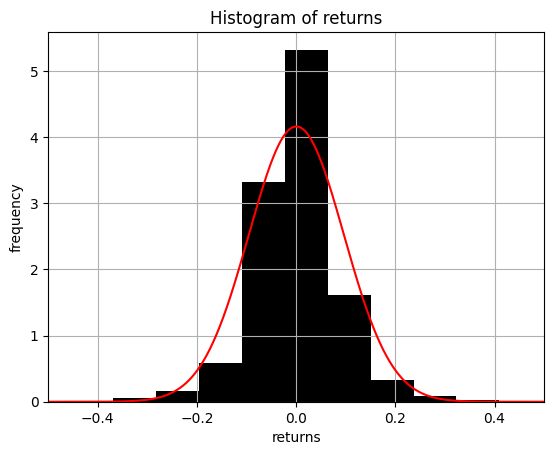

In [17]:
x = np.linspace(-0.5,0.5,1000)
y = norm.pdf(x, loc=np.mean(returns), scale=np.std(returns))

fig, ax = plt.subplots()

ax.plot(x,y, color="red")
ax.hist(returns, color= "black", bins= 30, density= True)
ax.set_title("Histogram of returns")
ax.grid(True)
ax.set_ylabel("frequency")
ax.set_xlabel("returns")
ax.set_xlim(-0.5,0.5)

plt.show()

We can see that the **central peak** of our distribution is higher than the peak of the Gaussian curve. The presence of **heavy tails** is not immediately obvious from the plot, but since the **total area under the Gaussian curve (red line) and under the histogram bars (black)** must each sum to one, the tails of our distribution must be **heavier than those of the Gaussian**, given that the black peak is taller and thinner than the red peak.

### 3.3 QQ plot vs. Normal for different degrees of freedom

Finally, we need to visualize **how far our distribution deviates from the normal** for different numbers of degrees of freedom $\nu$.

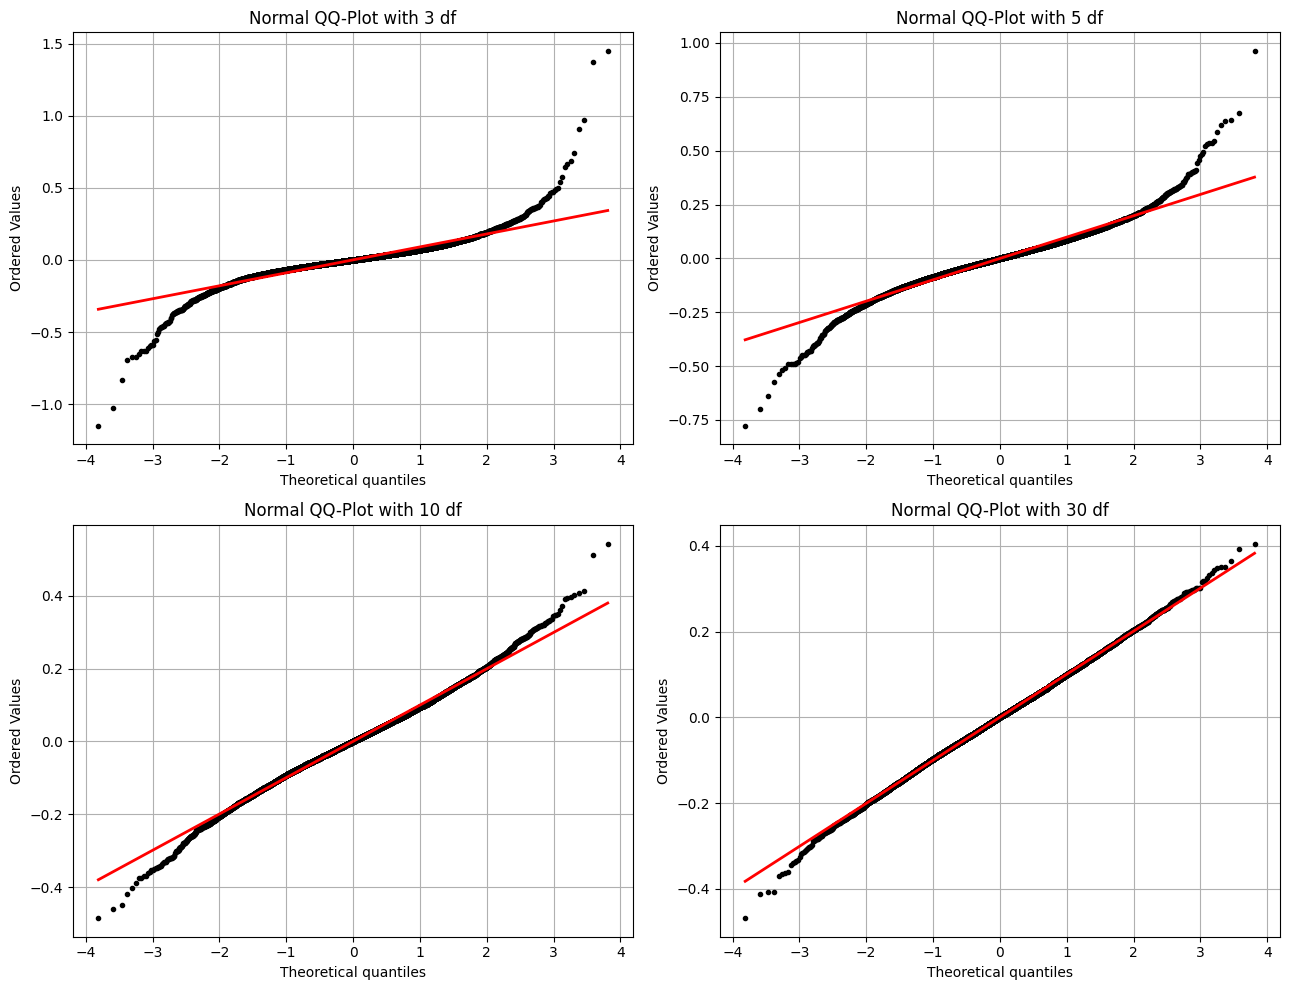

In [18]:
np.random.seed(42)

fig, ax = plt.subplots(2,2,figsize=(13,10))
ax = ax.flatten()

df = [3,5,10,30] #degrees of freedom
index = [0,1,2,3] #refering to each graphic

for i,j in zip(df, index): 
     epsilon = mu + math.sqrt(sigma*(i-2)/i)*np.random.standard_t(df=i, size=T)
     S = S0*np.exp(np.cumsum(epsilon))
     returns = np.diff(np.log(S))
     returns = returns[~np.isnan(returns)] 
     probplot(returns, dist="norm", fit= True, plot=ax[j])
     ax[j].get_lines()[0].set_color("black")   
     ax[j].get_lines()[1].set_color("red")
     ax[j].get_lines()[1].set_linewidth(2)
     ax[j].get_lines()[0].set_markersize(3)
     ax[j].set_title(f"Normal QQ-Plot with {i} df")
     ax[j].grid(True)

fig.tight_layout()
plt.show()


- When the **degrees of freedom** are 3, we are approaching the limit $\nu = 2$ beyond which the variance becomes infinite (trying a QQ-plot with 2 degrees of freedom produces very unusual results). In this case, the **heavy tails** are clearly visible.

- Degrees of freedom 5 and 10 are used to show the **progression** of the distribution as it **flattens**.

- 30 degrees of freedom is the **theoretical limit** beyond which the Student's t distribution is considered **practically Gaussian**.

Since these distributions work with degrees of freedom, we have much more flexibility. We can fine-tune the distribution ourselves, choosing anywhere from a standard Gaussian-like shape to something much more chaotic.  

## 4. Discussion of heavy tails

To discuss **heavy tails**, we will set the **degrees of freedom** to the minimum possible $\nu = 3$ so that the heavy tails are **most clearly visible**.

### 4.1 Estimation of the alpha exponent

Knowing that we have **heavy tails**, we want to check if they follow a **power-law** of the form:

$$
P(|r| > x) = C x^{-\alpha}
$$

Taking the logarithm of both sides, the **alpha exponent** can be estimated as the **slope** of the line obtained by plotting $P(|r| > x)$ against $x$. 

We would expect $\alpha$ to be between 2 and 4, and ideally to remain roughly constant even when changing the percentiles.

In [19]:
np.random.seed(42)

nu = 3
T = 10000 
S0 = 100 

epsilon = mu + math.sqrt(sigma*(nu-2)/nu)*np.random.standard_t(df=nu, size=T) 
S = S0*np.exp(np.cumsum(epsilon))
returns = np.diff(np.log(S))
returns = returns[~np.isnan(returns)]


x = np.sort(returns)
N = len(x)
y = (N - np.arange(N) - 1) / N 

percentile = [90,95,99,99.5]

for i in percentile: 
     threshold = np.percentile(x, i)
     mask = (x >= threshold) & (y > 0)
     log_x = np.log(x[mask])
     log_y = np.log(y[mask])
     result = linregress(log_x, log_y)
     print(f"Alfa for {i}th percentile: {- result.slope:.4f}")
     print(f"R: {- result.rvalue:.3f}")

Alfa for 90th percentile: 2.5481
R: 0.993
Alfa for 95th percentile: 2.8482
R: 0.997
Alfa for 99th percentile: 2.8926
R: 0.996
Alfa for 99.5th percentile: 2.7780
R: 0.993


We observe that the **alpha parameter** falls within the expected range (between 2 and 4) and remains **stable across different percentiles**. Therefore, we can conclude that the returns of a **t-Student random walk** are characterized by **heavy tails**, as expected, and that these heavy tails follow a **power-law** as described.

> With the large number of data points we have, even the regression calculated at the highest percentile is based on a sufficient number of observations.

## 5. Autocorrelation

We will compute both the **autocorrelation of returns** and the **autocorrelation of squared returns** to analyze the presence of large-scale structure or phenomena such as **volatility clustering**.

Obviously, we expect that neither autocorrelation will exceed what could be considered **white noise** at any lag, since the returns (constructed as **pseudorandom values** following a t-Student distribution) are **independent by design**.

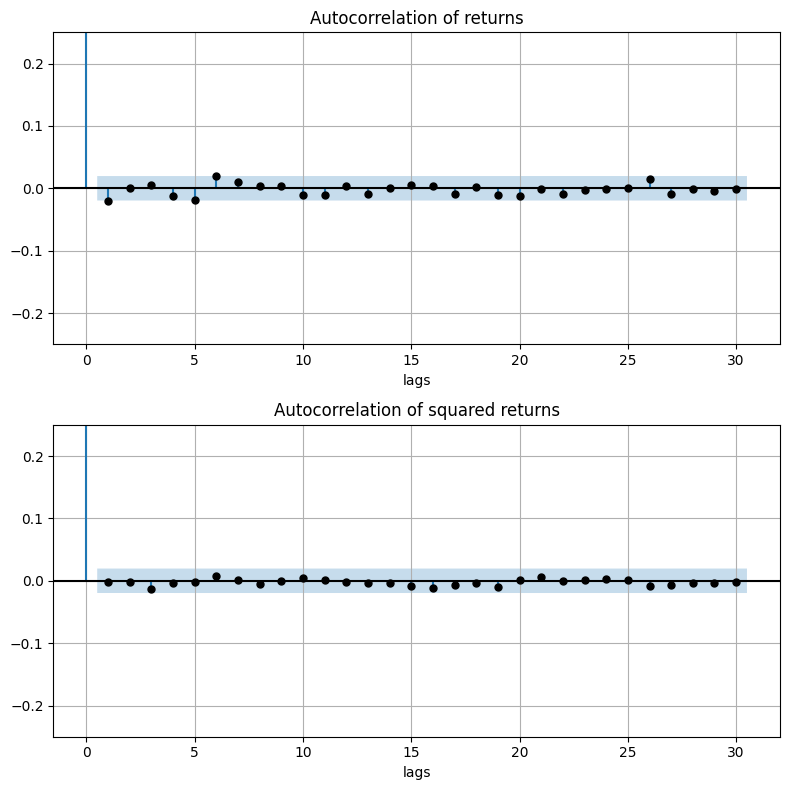

In [20]:
fig, ax = plt.subplots(2,1,figsize=(8,8), sharey= True)
plot_acf(returns, lags=30, ax=ax[0], color= "black") #autocorrelation of returns 
plot_acf(returns**2, lags=30, ax=ax[1], color= "black") #autocorrelation of squared returns 

ax[0].set_title("Autocorrelation of returns")
ax[1].set_title("Autocorrelation of squared returns")
ax[0].set_xlabel("lags")
ax[1].set_xlabel("lags")
ax[0].grid()
ax[1].grid()
ax[0].set_ylim(-0.25,0.25)
ax[1].set_ylim(-0.25,0.25)


plt.tight_layout()
plt.show()

From this, we conclude that **no autocorrelation** is observed in either the returns or the squared returns. Therefore, there is **no large-scale structure** or **volatility clustering** present. 

This is very important, as it demonstrates that the **higher probability of extreme events** compared to a Gaussian distribution does **not arise from correlation or trends**, these outliers simply occur naturally due to the heavy tailed distribution.

## 6. Summary of empirical findings and implications

In this project, we explored **t-Student random walks** to investigate the emergence of **heavy tails** and their implications for financial returns. The main empirical findings are:

- **Four moments analysis:** Returns exhibit moderate skewness but extremely high **excess kurtosis**, indicating the presence of **heavy tails**.
- **QQ plots for varying degrees of freedom:** Low degrees of freedom ($\nu = 3$) clearly show heavy tails, while higher degrees ($\nu = 30$) approach a Gaussian distribution.
- **Power-law behavior:** Heavy tails follow a **power-law** $P(|r| > x) \sim x^{-\alpha}$ with $\alpha$ between 2 and 4, stable across percentiles.
- **Autocorrelation analysis:** Both returns and squared returns show **no significant autocorrelation**, confirming the absence of volatility clustering or large-scale temporal structure.

**Implications:**  

These results highlight that many observed "extreme events" in financial markets can arise **solely from heavy-tailed distributions**, without requiring temporal correlations or trends. This provides a clear demonstration of why Student's t random walks are a simple yet powerful extension of Gaussian models, capturing key non-Gaussian features observed in real-world markets. However, this model fails when aproching an explanation for clustering volatility, assuming constant standard deviation over time.

## 7. References

- Mantegna, R. N., & Stanley, H. E. (2000). *An Introduction to Econophysics: Correlations and Complexity in Finance. Cambridge University Press.*

- MIT OpenCourseWare. *Mathematics in Applications to Finance*. https://ocw.mit.edu

## 8. Appendix

### Demonstration of the Central Limit Theorem (CLT)

We know that **any random variable**, regardless of its original distribution, will tend toward a **Gaussian distribution** when accumulated enough times. In our example, we have a random variable that by itself follows a Student’s t-distribution. 

Imagine that on day 0 we have the price $P_0$, and day by day we add returns drawn from a Student's t distribution (thus building the price iteratively). On day 5, the probability distribution governing the next shock that determines the price on day 6 will still be Student's t. However, by day 2000, with all accumulated returns, the distribution of the next shock determining the price on day 2001 will be **approximately Gaussian**.

To illustrate this, we will **simulate many Student's t random walks** and observe the distributions of prices on day 5 and day 2000. We expect that the latter distribution will resemble a Gaussian much more closely. 

It is important to note that the **Central Limit Theorem applies to accumulated returns, not to prices**. Therefore, our first step is to construct the **log-returns** for each time horizon (from day 4 to 5 and from day 1999 to 2000) for each random walk:

$$
r_5 = \ln\left(\frac{P_5}{P_4}\right), \quad \quad r_{2000} = \ln\left(\frac{P_{2000}}{P_{1999}}\right)
$$

> To simplify comparisons, we will **standardize both distributions**, making it easy to compare them directly.

In [21]:
np.random.seed(42)
N = 10000 
nu = 3.5

T = 5 

epsilon = mu + s*np.random.standard_t(df=nu, size=(T,N)) 
S = S0*np.exp(np.cumsum(epsilon, axis=0))
r5 = np.diff(np.log(S[-1]), axis=0)
r5 = r5[~np.isnan(r5)]
r5 = (r5 - np.mean(r5))/np.std(r5)


T = 2000 

epsilon = mu + s*np.random.standard_t(df=nu, size=(T,N)) 
S = S0*np.exp(np.cumsum(epsilon, axis=0))
r2000 = np.diff(np.log(S[-1]), axis=0)
r2000 = r2000[~np.isnan(r2000)]
r2000 = (r2000 - np.mean(r2000))/np.std(r2000)

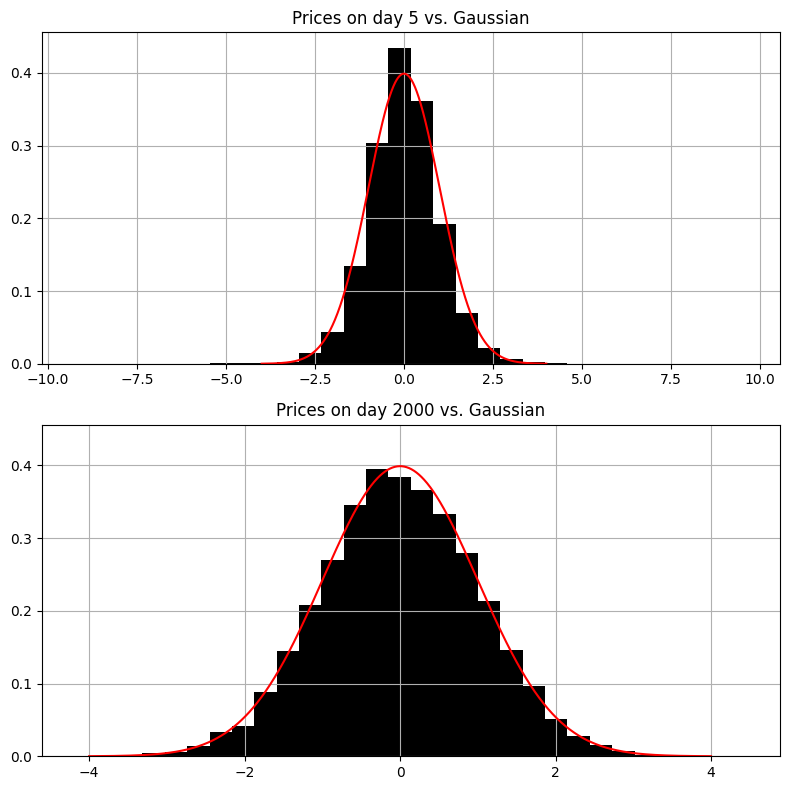

In [22]:
x = np.linspace(-4,4,1000) 
y = norm.pdf(x)


fig, ax = plt.subplots(2,1,figsize=(8,8),sharey= True)
ax[0].plot(x,y, color="red") 
ax[1].plot(x,y, color="red") 
ax[0].hist(r5, color= "black", bins= 30, density= True)
ax[1].hist(r2000, color= "black", bins= 30, density= True)
ax[0].set_title("Prices on day 5 vs. Gaussian")
ax[1].set_title("Prices on day 2000 vs. Gaussian")
ax[0].grid()
ax[1].grid()

fig.tight_layout()
plt.show()

We can clearly see that the second distribution resembles a **Gaussian** much more closely than the first, as the central peak of the 5-day distribution is considerably sharper.

An interesting detail is that in neither plot was the **x-axis manually limited**. Knowing that the Gaussian (red line) only extends to approximately ±4, it is clear that the first plot contains many more **outliers** than the second (hence the axis extends to ±10, even if they are not visible). 

This provides another **empirical demonstration** that the more returns are accumulated, the lower the probability of extreme values, and therefore, the closer the resulting distribution is to a Gaussian. 